# Chapter 16: The Stress-Strain Curve

*Companion notebook to Chapter 16, The Stress-Strain Curve.*

In 1858 David Kirkaldy measured the stretch of iron bars under load with a pair of compasses and found that the breaking load alone did not tell a good iron from a bad one. The shape of the curve mattered. This notebook builds three figures that make the same point for a strain gage user.

**This notebook demonstrates:**
1. A full A36 stress-strain curve (Figure 16.2), plotted at two zoom levels so the 0.2% offset construction is legible.
2. What two bonded gages and an extensometer read while a single Lüders front crosses a mild-steel specimen (Figure 16.3), with the strain limit of a general-purpose gage for comparison.
3. H. N. Hill's two hypothetical alloys (NACA TN 927, written 1943, issued 1944): the same modulus and the same 0.2% offset yield strength, but very different curves below yield (Figure 16.4), and what a gage on each reads at 60% of that yield strength.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book pulls the exact filenames from this folder.
OUT_DIR = Path("../src/media/ch16")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 0: Figure 16.2: A36 Steel Stress–Strain Curve with 0.2% Offset

Generates the full-range A36 curve shown as Figure 16.2. A zoom inset on the elastic/yield region makes the 0.2% offset construction visible at a readable scale: the main panel alone compresses 0.002 strain into an invisibly thin sliver against a 0.25 total range.

**A36 values used:**
- E = 200 GPa
- Upper yield: ~265 MPa; Lüders plateau: ~248 MPa
- UTS: 410 MPa at ε = 0.18 (within ASTM A36 range 400–550 MPa)
- Fracture at ε ≈ 0.22 (~22% elongation)

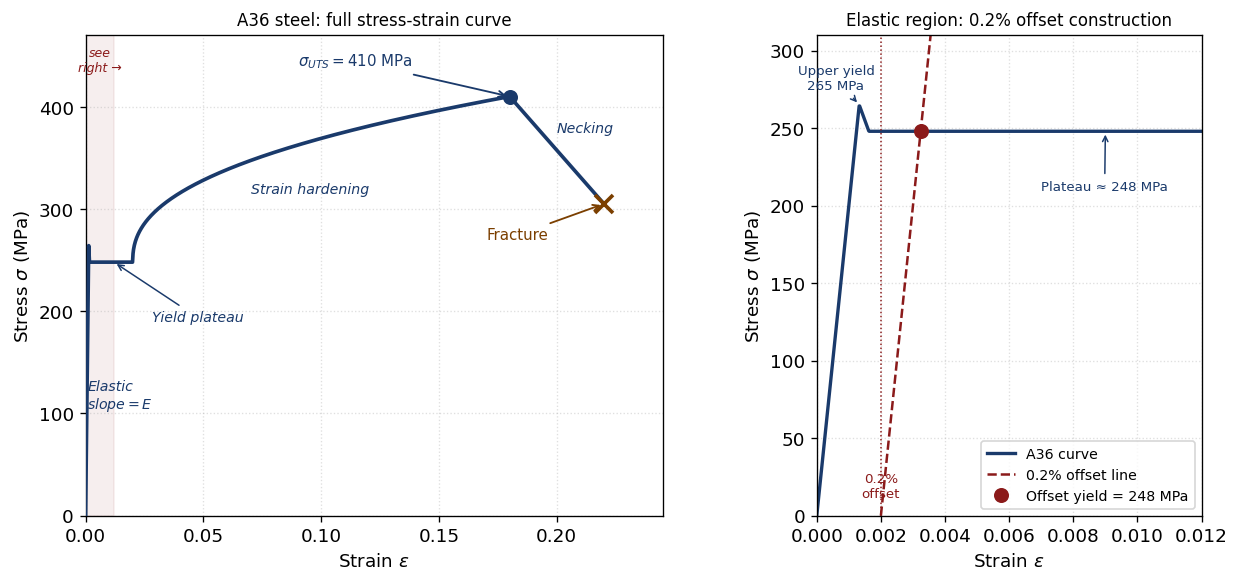

A36 offset yield: 248 MPa at ε = 0.00324 (3238 με)


In [2]:
# === Figure 16.2: A36 steel stress–strain curve — two-panel layout ===
# Left: full range with all labeled regions
# Right: elastic/yield zoom showing the 0.2% offset construction clearly
E_MPa = 200_000.0        # Young's modulus of A36 steel, MPa
OFFSET_STRAIN = 0.002    # 0.2% offset used to define the yield strength

# A36 piecewise geometry (ASTM A36: Fy ≥ 250 MPa / 36 ksi, Fu 400–550 MPa)
eps_yield_upper = 265.0 / E_MPa          # strain at top of upper yield spike
sig_yield_upper = 265.0                  # MPa
eps_drop_end    = eps_yield_upper + 0.0003
sig_plateau     = 248.0                  # MPa  lower yield / Lüders plateau (≈ 36 ksi)
eps_plateau_end = 0.020
sig_UTS         = 410.0                  # MPa  (within A36 range 400–550 MPa)
eps_UTS         = 0.18
sig_fracture    = 305.0                  # MPa  (engineering stress at neck fracture)
eps_fracture    = 0.22

def a36(e_arr):
    """Engineering stress (MPa) for an A36 steel specimen at each strain in ``e_arr``.

    Implements the idealized piecewise A36 response: linear elastic loading, an
    upper-yield spike that drops to the Lüders plateau, a power-law strain-hardening
    rise to the ultimate tensile strength, then a linear fall to fracture. Strains
    beyond fracture return NaN.
    """
    out = np.zeros_like(e_arr, dtype=float)
    for i, e in enumerate(e_arr):
        if e <= eps_yield_upper:
            out[i] = E_MPa * e
        elif e <= eps_drop_end:
            t = (e - eps_yield_upper) / (eps_drop_end - eps_yield_upper)
            out[i] = sig_yield_upper * (1.0 - t) + sig_plateau * t
        elif e <= eps_plateau_end:
            out[i] = sig_plateau
        elif e <= eps_UTS:
            t = (e - eps_plateau_end) / (eps_UTS - eps_plateau_end)
            out[i] = sig_plateau + (sig_UTS - sig_plateau) * t**0.42
        elif e <= eps_fracture:
            t = (e - eps_UTS) / (eps_fracture - eps_UTS)
            out[i] = sig_UTS + (sig_fracture - sig_UTS) * t
        else:
            out[i] = np.nan
    return out

eps_full = np.linspace(0, eps_fracture, 2000)
sig_full = a36(eps_full)

# 0.2% offset intersection: where the offset line (slope E, shifted by OFFSET_STRAIN)
# first crosses the stress–strain curve.
eps_search = np.linspace(OFFSET_STRAIN, 0.030, 10000)
diff = a36(eps_search) - E_MPa * (eps_search - OFFSET_STRAIN)
idx  = np.where(np.diff(np.sign(diff)))[0]
eps_y_off = float(eps_search[idx[0]])
sig_y_off = float(a36(np.array([eps_y_off]))[0])

NAVY     = '#1a3a6b'
DARK_RED = '#8b1a1a'
BROWN    = '#7b3f00'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2),
                                gridspec_kw={'width_ratios': [3, 2]})
fig.subplots_adjust(wspace=0.32)

# ── Left panel: full curve ────────────────────────────────────────────────────
ax1.plot(eps_full, sig_full, color=NAVY, lw=2.2, zorder=3)
ax1.plot(eps_UTS,      sig_UTS,      'o', color=NAVY,  ms=8,  zorder=5)
ax1.plot(eps_fracture, sig_fracture, 'x', color=BROWN, ms=11, mew=2.2, zorder=5)

ax1.annotate(f'$\\sigma_{{UTS}}={sig_UTS:.0f}$ MPa',
             xy=(eps_UTS, sig_UTS), xytext=(0.09, 440),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.1),
             color=NAVY, fontsize=9)
ax1.annotate('Fracture',
             xy=(eps_fracture, sig_fracture), xytext=(0.17, 270),
             arrowprops=dict(arrowstyle='->', color=BROWN, lw=1.1),
             color=BROWN, fontsize=9)

ax1.text(0.0008, 105, 'Elastic\n$slope=E$', color=NAVY, fontsize=8.5, style='italic')
ax1.annotate('Yield plateau', xy=(0.012, sig_plateau), xytext=(0.028, 190),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=0.9),
             color=NAVY, fontsize=8.5, style='italic')
ax1.text(0.070,  315, 'Strain hardening',    color=NAVY, fontsize=8.5, style='italic')
ax1.text(0.200,  375, 'Necking',             color=NAVY, fontsize=8.5, style='italic')

# shade zoom region
ax1.axvspan(0, 0.012, alpha=0.07, color=DARK_RED, zorder=0)
ax1.text(0.006, 435, 'see\nright →', color=DARK_RED, fontsize=7.5, ha='center', style='italic')

ax1.set_xlabel('Strain $\\varepsilon$', fontsize=11)
ax1.set_ylabel('Stress $\\sigma$ (MPa)', fontsize=11)
ax1.set_xlim(0, 0.245);  ax1.set_ylim(0, 470)
ax1.grid(True, ls=':', alpha=0.40)
ax1.set_title('A36 steel: full stress-strain curve', fontsize=10)

# ── Right panel: elastic / yield zoom ─────────────────────────────────────────
eps_z  = np.linspace(0, 0.012, 800)
sig_z  = a36(eps_z)
eps_oz = np.linspace(OFFSET_STRAIN, eps_y_off + 0.0015, 100)
sig_oz = E_MPa * (eps_oz - OFFSET_STRAIN)

ax2.plot(eps_z,  sig_z,  color=NAVY,     lw=2.0, label='A36 curve')
ax2.plot(eps_oz, sig_oz, color=DARK_RED, lw=1.5, ls='--', label='0.2% offset line')
ax2.plot(eps_y_off, sig_y_off, 'o', color=DARK_RED, ms=8, zorder=5,
         label=f'Offset yield = {sig_y_off:.0f} MPa')
ax2.axvline(OFFSET_STRAIN, color=DARK_RED, lw=0.9, ls=':')
ax2.text(OFFSET_STRAIN, 12, '0.2%\noffset', color=DARK_RED, fontsize=8, ha='center')

# Upper yield annotation — text placed right of the spike, below the spike peak
ax2.annotate(f'Upper yield\n{sig_yield_upper:.0f} MPa',
             xy=(eps_yield_upper, sig_yield_upper),
             xytext=(0.0006, 275),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=0.9),
             color=NAVY, fontsize=8, ha='center')
# Plateau annotation — to the right, mid-plateau
ax2.annotate(f'Plateau ≈ {sig_plateau:.0f} MPa',
             xy=(0.009, sig_plateau),
             xytext=(0.007, 210),
             arrowprops=dict(arrowstyle='->', color=NAVY, lw=0.9),
             color=NAVY, fontsize=8)

ax2.set_xlabel('Strain $\\varepsilon$', fontsize=11)
ax2.set_ylabel('Stress $\\sigma$ (MPa)', fontsize=11)
ax2.set_xlim(0, 0.012);  ax2.set_ylim(0, 310)
ax2.grid(True, ls=':', alpha=0.40)
# Legend bottom-right, clear of spike and offset construction
ax2.legend(fontsize=8.5, loc='lower right')
ax2.set_title('Elastic region: 0.2% offset construction', fontsize=10)

plt.savefig(OUT_DIR / 'fig16_2_stress_strain_curve.png', bbox_inches='tight', dpi=300)
plt.show()
print(f"A36 offset yield: {sig_y_off:.0f} MPa at ε = {eps_y_off:.5f} ({eps_y_off*1e6:.0f} με)")

---
## 1: Figure 16.3, a Lüders front passing under two gages

The idealized A36 curve of Figure 16.2 holds at the lower yield stress, 248 MPa, from the end of the elastic line to about 2.0% strain. On the specimen that plateau is not uniform straining. A band of yielded material, strained by the full Lüders strain (about 1.8% here), spreads along the gage section while the rest stays elastic at 248 / 200,000 = 1,240 µε.

The model below follows one front moving from one end of a 50 mm extensometer span to the other. Gage A is centered 10 mm from the end where the front starts; gage B at 35 mm. Each has a 3 mm grid. A gage reads the elastic strain until the front reaches its grid, then the average strain over its grid as the front crosses, then elastic plus Lüders strain. The extensometer reads the average over the whole span. Everything is plotted against the extensometer reading, which rises steadily with crosshead travel.

The horizontal line is the ±3% strain limit that Micro-Measurements TN-505 gives for EA-series gages with gage lengths under 3.2 mm.

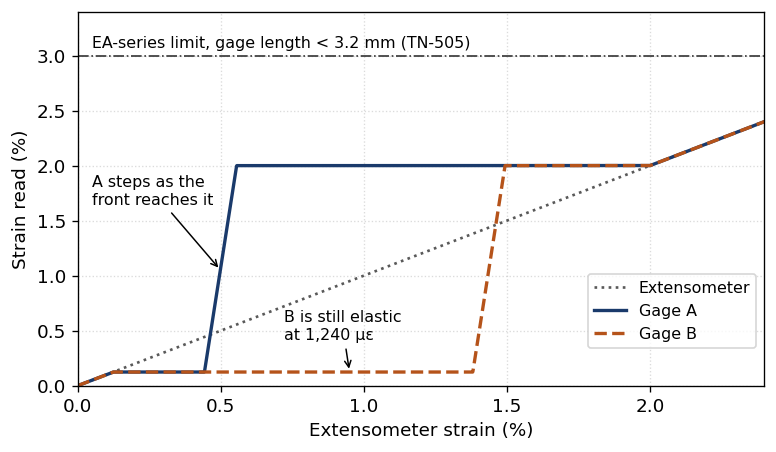

Elastic strain on the plateau: 1240 µε; Lüders strain: 1.88 %
Gage A: steps at extensometer 0.50 %, step size 18,760 µε over 1,126 µε of extensometer travel
Gage B: steps at extensometer 1.44 %, step size 18,760 µε over 1,126 µε of extensometer travel


In [3]:
# === Figure 16.3: what two bonded gages read as one Lüders front crosses the specimen ===
E_STEEL   = 200_000.0          # MPa
SIG_LOWER = 248.0              # MPa, lower yield (Lüders plateau) of the Figure 16.2 curve
EPS_EL    = SIG_LOWER / E_STEEL                # 0.00124 elastic strain on the plateau
EPS_L     = eps_plateau_end - EPS_EL           # Lüders strain, ~0.0188 (from the Fig 16.2 model)
SPAN_MM   = 50.0               # extensometer span
GRID_MM   = 3.0                # gage grid length
GAGES     = {'Gage A': 10.0, 'Gage B': 35.0}   # grid centers along the span
EA_LIMIT  = 0.03               # TN-505: EA series, gage length < 3.2 mm

ext = np.linspace(0.0, 0.024, 2400)            # extensometer (span-average) strain

def front_position(e_ext):
    # Front position (mm) from the starting end, for a span-average strain e_ext.
    frac = np.clip((e_ext - EPS_EL) / EPS_L, 0.0, 1.0)
    return frac * SPAN_MM

def gage_reading(e_ext, center):
    # Strain averaged over a grid centered at `center` (mm).
    if e_ext <= EPS_EL:
        return e_ext                           # elastic loading, uniform
    if e_ext >= EPS_EL + EPS_L:
        return e_ext                           # plateau finished: uniform hardening
    x = front_position(e_ext)
    lo, hi = center - GRID_MM / 2, center + GRID_MM / 2
    yielded = np.clip((x - lo) / GRID_MM, 0.0, 1.0)   # fraction of grid behind the front
    return EPS_EL + EPS_L * yielded

fig, ax = plt.subplots(figsize=(6.6, 3.9))
ax.plot(ext * 100, ext * 100, color='0.35', lw=1.6, ls=':', label='Extensometer')
styles = [dict(color='#1a3a6b', lw=2.0, ls='-'), dict(color='#b5531a', lw=2.0, ls='--')]
step_at = {}
for (name, c), st in zip(GAGES.items(), styles):
    r = np.array([gage_reading(e, c) for e in ext])
    ax.plot(ext * 100, r * 100, label=name, **st)
    step_at[name] = EPS_EL + EPS_L * c / SPAN_MM
ax.axhline(EA_LIMIT * 100, color='0.2', lw=1.0, ls='-.')
ax.text(0.05, EA_LIMIT * 100 + 0.07, 'EA-series limit, gage length < 3.2 mm (TN-505)', fontsize=9.5)

# Direct labels on the two steps
ax.annotate('A steps as the\nfront reaches it', xy=(step_at['Gage A'] * 100, 1.05),
            xytext=(0.05, 1.65), fontsize=9.5, arrowprops=dict(arrowstyle='->', lw=0.9))
ax.annotate('B is still elastic\nat 1,240 µε', xy=(0.95, EPS_EL * 100), xytext=(0.72, 0.42),
            fontsize=9.5, arrowprops=dict(arrowstyle='->', lw=0.9))
ax.set_xlabel('Extensometer strain (%)')
ax.set_ylabel('Strain read (%)')
ax.set_xlim(0, 2.4); ax.set_ylim(0, 3.4)
ax.grid(True, ls=':', alpha=0.45)
ax.legend(fontsize=9.5, loc='lower right', bbox_to_anchor=(1.0, 0.08))
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig16_nb1_luders_gage_readings.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Elastic strain on the plateau: {EPS_EL*1e6:.0f} µε; Lüders strain: {EPS_L*100:.2f} %")
for name, c in GAGES.items():
    print(f"{name}: steps at extensometer {step_at[name]*100:.2f} %, "
          f"step size {EPS_L*1e6:,.0f} µε over {EPS_L*GRID_MM/SPAN_MM*1e6:,.0f} µε of extensometer travel")

---
## 2: Figure 16.4, two alloys with one yield strength (Hill, NACA TN 927)

H. N. Hill of the Aluminum Company of America wrote the Ramberg-Osgood curve in terms of offset yield strengths:

$$\varepsilon = \frac{\sigma}{E} + 0.002\left(\frac{\sigma}{\sigma_{0.2}}\right)^{n}, \qquad n = \frac{\log 2}{\log(\sigma_{0.2}/\sigma_{0.1})}$$

His illustration (TN 927 asks the reader to "consider two alloys"; they are hypothetical): two alloys, both with $E$ = 10,000,000 psi (69 GPa) and $\sigma_{0.2}$ = 50,000 psi (345 MPa). Alloy A has a 0.1% offset strength of 43,000 psi (296 MPa), so $n$ = 4.59; alloy B has 48,000 psi (331 MPa), so $n$ = 16.8. The chapter's worked example uses the rounded values 4.6 and 17.

Left panel: the two curves through the shared offset yield point. Right panel: the deviation from Hooke's law on log-log axes, where each curve is a straight line of slope $n$ (Ramberg and Osgood, NACA TN 902, eq. 10).

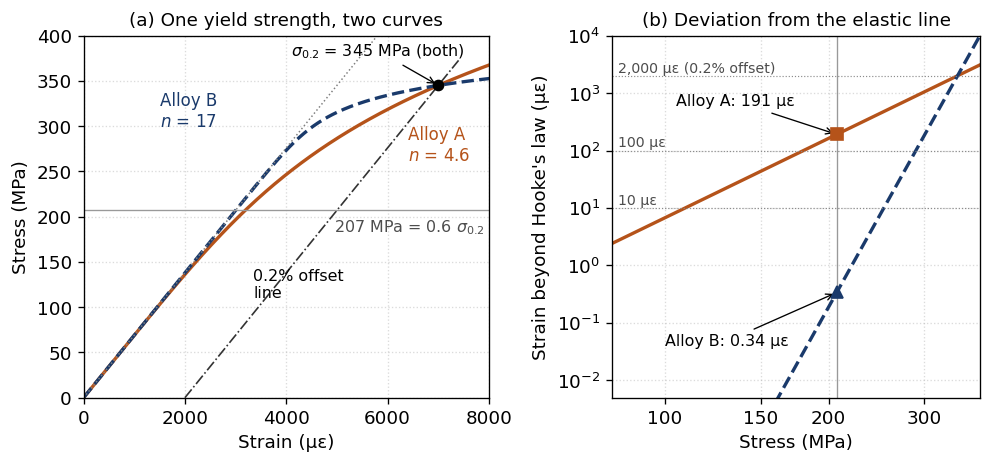

Alloy A (n = 4.6): deviation at 207 MPa = 190.78 µε; gage reads 3,191 µε; sigma = E*eps gives 220 MPa (6.4 % high)
   deviation reaches 10 µε at 109 MPa
   deviation reaches 100 µε at 180 MPa
Alloy B (n = 17.0): deviation at 207 MPa = 0.34 µε; gage reads 3,000 µε; sigma = E*eps gives 207 MPa (0.0 % high)
   deviation reaches 10 µε at 253 MPa
   deviation reaches 100 µε at 289 MPa


In [4]:
# === Figure 16.4: Hill's alloys A and B, same E and same 0.2% offset yield ===
E_AL   = 69_000.0       # MPa (10,000,000 psi)
S02    = 345.0          # MPa (50,000 psi), shared 0.2% offset yield strength
ALLOYS = {'A': 4.6, 'B': 17.0}    # Hill's n = 4.59 and 16.8, rounded
S_WORK = 207.0          # MPa, 60% of S02 (30,000 psi)

def ro_strain(s, n):
    # Ramberg-Osgood total strain in Hill's offset form.
    return s / E_AL + 0.002 * (s / S02) ** n

def deviation(s, n):
    return 0.002 * (s / S02) ** n

s = np.linspace(0.0, 380.0, 800)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.4, 4.0), gridspec_kw={'width_ratios': [1.1, 1]})
st = {'A': dict(color='#b5531a', lw=2.0, ls='-'), 'B': dict(color='#1a3a6b', lw=2.0, ls='--')}

# Left: stress-strain curves through the common offset point
for k, n in ALLOYS.items():
    ax1.plot(ro_strain(s, n) * 1e6, s, **st[k])
e_el = np.linspace(0, 6000, 50)
ax1.plot(e_el, E_AL * e_el * 1e-6, color='0.5', lw=0.9, ls=':')
e_off = np.linspace(2000, 7400, 50)
ax1.plot(e_off, E_AL * (e_off - 2000) * 1e-6, color='0.2', lw=1.0, ls='-.')
ax1.plot(ro_strain(S02, 4.6) * 1e6, S02, 'o', color='k', ms=6, zorder=5)
ax1.annotate('$\\sigma_{0.2}$ = 345 MPa (both)', xy=(ro_strain(S02, 4.6) * 1e6, S02),
             xytext=(4100, 378), fontsize=9.5, arrowprops=dict(arrowstyle='->', lw=0.8))
ax1.axhline(S_WORK, color='0.6', lw=0.8)
ax1.text(4950, S_WORK - 24, '207 MPa = 0.6 $\\sigma_{0.2}$', fontsize=9.5, color='0.3')
ax1.text(6400, 262, 'Alloy A\n$n$ = 4.6', fontsize=10, color=st['A']['color'])
ax1.text(1500, 300, 'Alloy B\n$n$ = 17', fontsize=10, color=st['B']['color'])
ax1.text(3350, 110, '0.2% offset\nline', fontsize=9.5)
ax1.set_xlim(0, 8000); ax1.set_ylim(0, 400)
ax1.set_xlabel('Strain (µε)'); ax1.set_ylabel('Stress (MPa)')
ax1.set_title('(a) One yield strength, two curves', fontsize=11)
ax1.grid(True, ls=':', alpha=0.45)

# Right: deviation from Hooke's law, log-log
s_log = np.logspace(np.log10(80), np.log10(380), 200)
for k, n in ALLOYS.items():
    ax2.loglog(s_log, deviation(s_log, n) * 1e6, **st[k])
    d = deviation(S_WORK, n) * 1e6
    ax2.plot(S_WORK, d, 's' if k == 'A' else '^', color=st[k]['color'], ms=7, zorder=5)
ax2.annotate('Alloy A: 191 µε', xy=(S_WORK, deviation(S_WORK, 4.6) * 1e6), xytext=(105, 600),
             fontsize=9.5, arrowprops=dict(arrowstyle='->', lw=0.8))
ax2.annotate('Alloy B: 0.34 µε', xy=(S_WORK, deviation(S_WORK, 17) * 1e6), xytext=(100, 0.04),
             fontsize=9.5, arrowprops=dict(arrowstyle='->', lw=0.8))
for lvl, lab in [(10, '10 µε'), (100, '100 µε'), (2000, '2,000 µε (0.2% offset)')]:
    ax2.axhline(lvl, color='0.55', lw=0.7, ls=':')
    ax2.text(82, lvl * 1.15, lab, fontsize=8.5, color='0.3')
ax2.axvline(S_WORK, color='0.6', lw=0.8)
ax2.set_xlim(80, 380); ax2.set_ylim(0.005, 10000)
ax2.set_xticks([100, 150, 200, 300]); ax2.set_xticklabels(['100', '150', '200', '300'])
ax2.minorticks_off()
ax2.set_xlabel('Stress (MPa)'); ax2.set_ylabel('Strain beyond Hooke\'s law (µε)')
ax2.set_title('(b) Deviation from the elastic line', fontsize=11)
ax2.grid(True, which='major', ls=':', alpha=0.45)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig16_nb2_same_yield_two_alloys.png', bbox_inches='tight', dpi=300)
plt.show()

eps_hooke = S_WORK / E_AL
for k, n in ALLOYS.items():
    d = deviation(S_WORK, n)
    s_from_gage = E_AL * (eps_hooke + d)
    print(f"Alloy {k} (n = {n}): deviation at {S_WORK:.0f} MPa = {d*1e6:.2f} µε; gage reads "
          f"{(eps_hooke+d)*1e6:,.0f} µε; sigma = E*eps gives {s_from_gage:.0f} MPa "
          f"({(s_from_gage/S_WORK-1)*100:.1f} % high)")
    for lvl in (10e-6, 100e-6):
        print(f"   deviation reaches {lvl*1e6:.0f} µε at {S02*(lvl/0.002)**(1/n):.0f} MPa")

---
## Where to take this next

1. **Overlay true stress and true strain.** The chapter gives the conversions $\sigma_{\text{true}} = \sigma_{\text{eng}}(1+\varepsilon_{\text{eng}})$ and $\varepsilon_{\text{true}} = \ln(1+\varepsilon_{\text{eng}})$ (Eqs. 16.2 and 16.3). Plot both alongside the A36 curve and see where they diverge, and where the conversion stops being valid once necking begins.
2. **Fit Hill's form to a test record.** Take any measured curve, read off the 0.1% and 0.2% offset strengths, compute $n$, and compare the fitted curve with the data below yield. Chapter 53 fits the same form to a synthetic aluminum record.
3. **Move the gages.** In the Lüders cell, change the gage positions and grid length. A longer grid stretches the step over more extensometer travel; it never makes the step smaller.